Part 1: Setup and Data Preparation
Using device: cpu

Part 2: Define and Train Model
Epoch [20/100], Loss: 0.6401
Epoch [40/100], Loss: 0.4691
Epoch [60/100], Loss: 0.2375
Epoch [80/100], Loss: 0.1395
Epoch [100/100], Loss: 0.1123

Training complete!

Part 3: Calculate Metrics with sklearn
Classification Metrics:
  Accuracy:  0.8850
  Precision: 0.8889
  Recall:    0.8800
  F1-Score:  0.8844

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.89      0.89       100
     Class 1       0.89      0.88      0.88       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200


Part 4: Confusion Matrix
Confusion Matrix:
[[89 11]
 [12 88]]

TP=88, TN=89, FP=11, FN=12

Confusion Matrix Explained:
                Predicted
           Positive    Negative
Actual  Pos    TP         FN
        Neg    FP         TN

TP = Tru

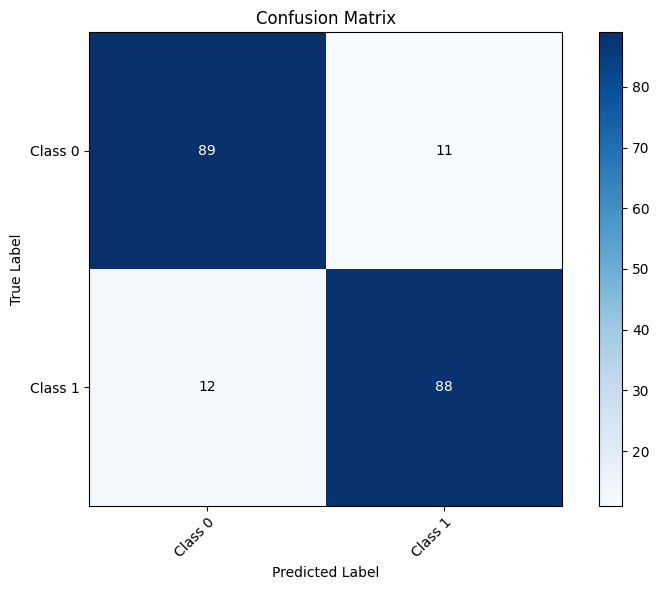


Part 6: Understanding Precision vs Recall
Precision vs Recall Trade-off:

High Precision, Low Recall:
  - Very confident when predicting positive
  - Few false positives
  - But misses many actual positives
  Example: Spam filter (don't mark legitimate email as spam)

Low Precision, High Recall:
  - Catches most actual positives
  - Many false positives
  - Better to be safe than sorry
  Example: Disease screening (don't miss sick patients)

This model:
  Precision: 0.8889 - Of all predicted positive, 88.9% are correct
  Recall:    0.8800 - Of all actual positive, 88.0% are caught

Part 7: Using torchmetrics
torchmetrics not installed.
Install with: pip install torchmetrics

Part 8: Multi-Class Metrics
Multi-class Metrics:
  Accuracy:  1.0000
  Precision: 1.0000 (macro)
  Recall:    1.0000 (macro)
  F1-Score:  1.0000 (macro)

Confusion Matrix:
[[50  0  0  0]
 [ 0 50  0  0]
 [ 0  0 50  0]
 [ 0  0  0 50]]


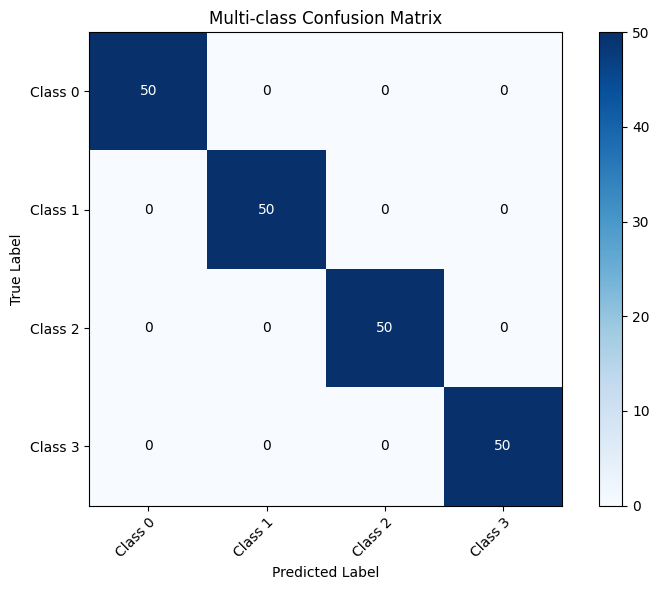


Part 9: Comparing Models
When comparing models, use multiple metrics:
  1. Accuracy - Overall correctness
  2. Precision - How many predicted positives are correct
  3. Recall - How many actual positives were caught
  4. F1-Score - Balance between precision and recall

Which metric matters most depends on your problem:
  - Spam detection: High precision (don't delete legitimate emails)
  - Disease screening: High recall (don't miss sick patients)
  - Balanced dataset: Accuracy is fine
  - Imbalanced dataset: Use F1-score or precision/recall

Exercises

Exercise 1: Metrics on imbalanced data
Create imbalanced dataset (90% class 0, 10% class 1)
Compare accuracy vs F1-score
Tip: Use make_circles with different sample weights

Exercise 2: Optimize for precision vs recall
Try different thresholds:
  - Higher threshold (0.7) -> Higher precision, lower recall
  - Lower threshold (0.3) -> Lower precision, higher recall
Tip: Modify (test_probs > 0.5) threshold

Exercise 3: Compare averaging me

In [14]:
"""
Exercise 5: Evaluation Metrics
Neural Network Classification - Module 3

This exercise covers:
- Setting up torchmetrics
- Calculating accuracy, precision, recall, F1-score
- Creating confusion matrices
- Visualizing confusion matrices
- Comparing models using multiple metrics

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Setup and Data Preparation
# ============================================

print("=" * 60)
print("Part 1: Setup and Data Preparation")
print("=" * 60)

# Create binary classification dataset
X, y = make_circles(n_samples=1000, noise=0.15, factor=0.5, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# ============================================
# Part 2: Define and Train Model
# ============================================

print("\n" + "=" * 60)
print("Part 2: Define and Train Model")
print("=" * 60)

# Define non-linear model
class BinaryClassifier(nn.Module):
    def __init__(self):
        super(BinaryClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layers(x)

model = BinaryClassifier().to(device)

# Train model
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    loss = criterion(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("\nTraining complete!")

# ============================================
# Part 3: Calculate Metrics with sklearn
# ============================================

print("\n" + "=" * 60)
print("Part 3: Calculate Metrics with sklearn")
print("=" * 60)

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs > 0.5).long()

# Convert to numpy for sklearn
y_true = y_test.cpu().numpy().squeeze()
y_pred = test_preds.cpu().numpy().squeeze()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Classification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

# ============================================
# Part 4: Confusion Matrix
# ============================================

print("\n" + "=" * 60)
print("Part 4: Confusion Matrix")
print("=" * 60)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nTP={cm[1,1]}, TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}")

# Explain the confusion matrix
print("\nConfusion Matrix Explained:")
print("                Predicted")
print("           Positive    Negative")
print("Actual  Pos    TP         FN")
print("        Neg    FP         TN")
print("\nTP = True Positive  (correctly predicted positive)")
print("TN = True Negative  (correctly predicted negative)")
print("FP = False Positive (incorrectly predicted positive)")
print("FN = False Negative (incorrectly predicted negative)")

# ============================================
# Part 5: Visualizing Confusion Matrix
# ============================================

print("\n" + "=" * 60)
print("Part 5: Visualizing Confusion Matrix")
print("=" * 60)

def plot_confusion_matrix(cm, class_names=None, title='Confusion Matrix'):
    """Plot confusion matrix with annotations"""
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(cm))]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # Configure axes
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        title=title,
        ylabel='True Label',
        xlabel='Predicted Label'
    )

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    # Annotate cells
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha='center', va='center',
                   color='white' if cm[i, j] > thresh else 'black')

    fig.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names=['Class 0', 'Class 1'])

# ============================================
# Part 6: Understanding Precision vs Recall
# ============================================

print("\n" + "=" * 60)
print("Part 6: Understanding Precision vs Recall")
print("=" * 60)

print("Precision vs Recall Trade-off:")
print("\nHigh Precision, Low Recall:")
print("  - Very confident when predicting positive")
print("  - Few false positives")
print("  - But misses many actual positives")
print("  Example: Spam filter (don't mark legitimate email as spam)")

print("\nLow Precision, High Recall:")
print("  - Catches most actual positives")
print("  - Many false positives")
print("  - Better to be safe than sorry")
print("  Example: Disease screening (don't miss sick patients)")

print(f"\nThis model:")
print(f"  Precision: {precision:.4f} - Of all predicted positive, {precision*100:.1f}% are correct")
print(f"  Recall:    {recall:.4f} - Of all actual positive, {recall*100:.1f}% are caught")

# ============================================
# Part 7: Using torchmetrics
# ============================================

print("\n" + "=" * 60)
print("Part 7: Using torchmetrics")
print("=" * 60)

try:
    from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix

    # Setup metrics
    accuracy_metric = Accuracy(task='binary')
    precision_metric = Precision(task='binary')
    recall_metric = Recall(task='binary')
    f1_metric = F1Score(task='binary')
    confmat_metric = ConfusionMatrix(task='binary')

    # Calculate metrics
    acc = accuracy_metric(test_preds, y_test)
    prec = precision_metric(test_preds, y_test)
    rec = recall_metric(test_preds, y_test)
    f1 = f1_metric(test_preds, y_test)
    cm_tm = confmat_metric(test_preds, y_test)

    print("torchmetrics Results:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm_tm}")

except ImportError:
    print("torchmetrics not installed.")
    print("Install with: pip install torchmetrics")

# ============================================
# Part 8: Multi-Class Metrics
# ============================================

print("\n" + "=" * 60)
print("Part 8: Multi-Class Metrics")
print("=" * 60)

# Create multi-class dataset
X_multi, y_multi = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# Convert to tensors
X_test_m = torch.FloatTensor(X_test_m).to(device)
y_test_m = torch.LongTensor(y_test_m).to(device)

# Train simple multi-class model
class MultiClassClassifier(nn.Module):
    def __init__(self):
        super(MultiClassClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        return self.layers(x)

model_m = MultiClassClassifier().to(device)

# Train
criterion_m = nn.CrossEntropyLoss()
optimizer_m = optim.Adam(model_m.parameters(), lr=0.01)

for epoch in range(100):
    model_m.train()
    outputs = model_m(torch.FloatTensor(X_train_m).to(device))
    loss = criterion_m(outputs, torch.LongTensor(y_train_m).to(device))
    optimizer_m.zero_grad()
    loss.backward()
    optimizer_m.step()

# Make predictions
model_m.eval()
with torch.inference_mode():
    test_logits_m = model_m(X_test_m)
    test_preds_m = torch.argmax(test_logits_m, dim=1)

# Calculate metrics
y_true_m = y_test_m.cpu().numpy()
y_pred_m = test_preds_m.cpu().numpy()

accuracy_m = accuracy_score(y_true_m, y_pred_m)
precision_m = precision_score(y_true_m, y_pred_m, average='macro')
recall_m = recall_score(y_true_m, y_pred_m, average='macro')
f1_m = f1_score(y_true_m, y_pred_m, average='macro')

print("Multi-class Metrics:")
print(f"  Accuracy:  {accuracy_m:.4f}")
print(f"  Precision: {precision_m:.4f} (macro)")
print(f"  Recall:    {recall_m:.4f} (macro)")
print(f"  F1-Score:  {f1_m:.4f} (macro)")

# Confusion matrix
cm_m = confusion_matrix(y_true_m, y_pred_m)
print(f"\nConfusion Matrix:")
print(cm_m)

# Plot multi-class confusion matrix
plot_confusion_matrix(cm_m, class_names=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
                     title='Multi-class Confusion Matrix')

# ============================================
# Part 9: Comparing Models
# ============================================

print("\n" + "=" * 60)
print("Part 9: Comparing Models")
print("=" * 60)

print("When comparing models, use multiple metrics:")
print("  1. Accuracy - Overall correctness")
print("  2. Precision - How many predicted positives are correct")
print("  3. Recall - How many actual positives were caught")
print("  4. F1-Score - Balance between precision and recall")

print("\nWhich metric matters most depends on your problem:")
print("  - Spam detection: High precision (don't delete legitimate emails)")
print("  - Disease screening: High recall (don't miss sick patients)")
print("  - Balanced dataset: Accuracy is fine")
print("  - Imbalanced dataset: Use F1-score or precision/recall")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Metrics on imbalanced data
print("\nExercise 1: Metrics on imbalanced data")
print("Create imbalanced dataset (90% class 0, 10% class 1)")
print("Compare accuracy vs F1-score")
print("Tip: Use make_circles with different sample weights")

# Exercise 2: Optimize for precision vs recall
print("\nExercise 2: Optimize for precision vs recall")
print("Try different thresholds:")
print("  - Higher threshold (0.7) -> Higher precision, lower recall")
print("  - Lower threshold (0.3) -> Lower precision, higher recall")
print("Tip: Modify (test_probs > 0.5) threshold")

# Exercise 3: Compare different averaging methods
print("\nExercise 3: Compare averaging methods")
print("For multi-class, try different averaging:")
print("  - average='macro' (equal weight per class)")
print("  - average='weighted' (weight by class size)")
print("  - average='micro' (global counts)")
print("Tip: Modify the 'average' parameter")

# Exercise 4: Create custom metric
print("\nExercise 4: Create custom metric")
print("Implement a custom metric:")
print("  - Specificity = TN / (TN + FP)")
print("  - False Positive Rate")
print("Tip: Use sklearn.metrics functions")

# Exercise 5: Per-class metrics for multi-class
print("\nExercise 5: Per-class metrics")
print("Calculate precision/recall/F1 for each class separately")
print("Which class is hardest to classify?")
print("Tip: Iterate through each class and calculate metrics")

print("\n" + "=" * 60)
print("Exercise 5 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Metrics on imbalanced data
- Create imbalanced dataset (90% class 0, 10% class 1)
- Compare accuracy vs F1-score

In [3]:
from sklearn.datasets import make_classification

# Create imbalanced dataset (90% class 0, 10% class 1)

X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    random_state=42
)

# Split data
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

# Convert to tensors
X_train_imb = torch.FloatTensor(X_train_imb).to(device)
y_train_imb = torch.FloatTensor(y_train_imb).unsqueeze(1).to(device)
X_test_imb = torch.FloatTensor(X_test_imb).to(device)
y_test_imb = torch.FloatTensor(y_test_imb).unsqueeze(1).to(device)

print(f"Class distribution in training set:")
print(f"  Class 0: {(y_train_imb == 0).sum().item()} ({(y_train_imb == 0).sum().item() / len(y_train_imb) * 100:.1f}%)")
print(f"  Class 1: {(y_train_imb == 1).sum().item()} ({(y_train_imb == 1).sum().item() / len(y_train_imb) * 100:.1f}%)")

# Train model on imbalanced data
model_imb = BinaryClassifier().to(device)
criterion_imb = nn.BCEWithLogitsLoss()
optimizer_imb = optim.Adam(model_imb.parameters(), lr=0.01)

for epoch in range(100):
    model_imb.train()
    y_logits = model_imb(X_train_imb)
    loss = criterion_imb(y_logits, y_train_imb)
    optimizer_imb.zero_grad()
    loss.backward()
    optimizer_imb.step()

# Make predictions
model_imb.eval()
with torch.inference_mode():
    test_logits_imb = model_imb(X_test_imb)
    test_probs_imb = torch.sigmoid(test_logits_imb)
    test_preds_imb = (test_probs_imb > 0.5).long()

# Convert to numpy
y_true_imb = y_test_imb.cpu().numpy().squeeze()
y_pred_imb = test_preds_imb.cpu().numpy().squeeze()

# Calculate metrics
acc_imb = accuracy_score(y_true_imb, y_pred_imb)
f1_imb = f1_score(y_true_imb, y_pred_imb)
prec_imb = precision_score(y_true_imb, y_pred_imb)
rec_imb = recall_score(y_true_imb, y_pred_imb)

print("\nMetrics on Imbalanced Data:")
print(f"  Accuracy:  {acc_imb:.4f}")
print(f"  Precision: {prec_imb:.4f}")
print(f"  Recall:    {rec_imb:.4f}")
print(f"  F1-Score:  {f1_imb:.4f}") 

Class distribution in training set:
  Class 0: 716 (89.5%)
  Class 1: 84 (10.5%)

Metrics on Imbalanced Data:
  Accuracy:  0.9750
  Precision: 0.9444
  Recall:    0.8095
  F1-Score:  0.8718


# Exercise 2: Optimize for precision vs recall
Try different thresholds:
- Higher threshold (0.7) -> Higher precision, lower recall
- Lower threshold (0.3) -> Lower precision, higher recall


Threshold = 0.3:
  Accuracy:  0.9850
  Precision: 0.9500
  Recall:    0.9048
  F1-Score:  0.9268

Threshold = 0.5:
  Accuracy:  0.9750
  Precision: 0.9444
  Recall:    0.8095
  F1-Score:  0.8718

Threshold = 0.7:
  Accuracy:  0.9700
  Precision: 1.0000
  Recall:    0.7143
  F1-Score:  0.8333


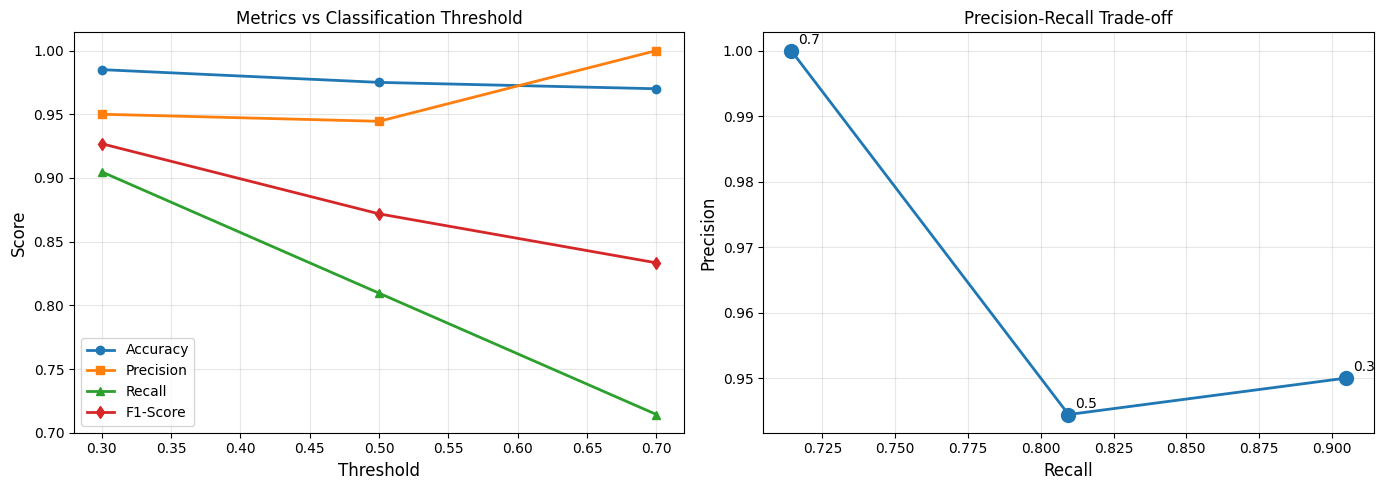

In [5]:
# Test different thresholds
thresholds = [0.3, 0.5, 0.7]
results = []

for threshold in thresholds:
    # Apply threshold
    test_preds_threshold = (test_probs_imb > threshold).long()
    y_pred_threshold = test_preds_threshold.cpu().numpy().squeeze()
    
    # Calculate metrics
    acc = accuracy_score(y_true_imb, y_pred_threshold)
    prec = precision_score(y_true_imb, y_pred_threshold, zero_division=0)
    rec = recall_score(y_true_imb, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_true_imb, y_pred_threshold, zero_division=0)
    
    results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\nThreshold = {threshold}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Visualize threshold comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrics vs Threshold
metrics_df = {
    'Threshold': [r['Threshold'] for r in results],
    'Accuracy': [r['Accuracy'] for r in results],
    'Precision': [r['Precision'] for r in results],
    'Recall': [r['Recall'] for r in results],
    'F1-Score': [r['F1-Score'] for r in results]
}

axes[0].plot(metrics_df['Threshold'], metrics_df['Accuracy'], 'o-', label='Accuracy', linewidth=2)
axes[0].plot(metrics_df['Threshold'], metrics_df['Precision'], 's-', label='Precision', linewidth=2)
axes[0].plot(metrics_df['Threshold'], metrics_df['Recall'], '^-', label='Recall', linewidth=2)
axes[0].plot(metrics_df['Threshold'], metrics_df['F1-Score'], 'd-', label='F1-Score', linewidth=2)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Classification Threshold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision vs Recall Trade-off
axes[1].plot(metrics_df['Recall'], metrics_df['Precision'], 'o-', linewidth=2, markersize=10)
for i, threshold in enumerate(metrics_df['Threshold']):
    axes[1].annotate(f'{threshold}', 
                    (metrics_df['Recall'][i], metrics_df['Precision'][i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Trade-off', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exercise 3: Compare different averaging methods
For multi-class, try different averaging:
- average='macro' (equal weight per class)
- average='weighted' (weight by class size)
- average='micro' (global counts)

Comparing Averaging Methods for Multi-class Metrics:

Average = 'macro':
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Average = 'weighted':
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Average = 'micro':
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000



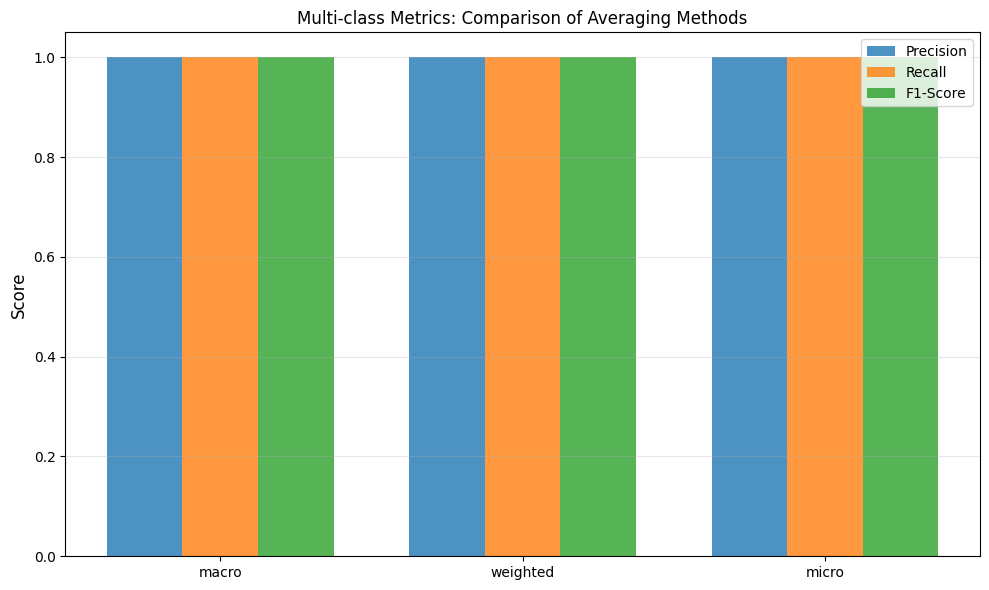

Explanation of Averaging Methods:

1. 'macro' - Equal weight per class
   - Simple average of metrics for each class
   - Best when all classes are equally important
   - Result: 1.0000

2. 'weighted' - Weight by class size
   - Weighted average by class support
   - Best for imbalanced datasets
   - Result: 1.0000

3. 'micro' - Global counts
   - Calculate metrics globally by counting TP/FP/TN/FN
   - Same as accuracy for multi-class
   - Result: 1.0000


In [15]:
# Compare different averaging methods for multi-class metrics
averaging_methods = ['macro', 'weighted', 'micro']
results_averaging = []

print("Comparing Averaging Methods for Multi-class Metrics:\n")

for avg_method in averaging_methods:
    prec = precision_score(y_true_m, y_pred_m, average=avg_method, zero_division=0)
    rec = recall_score(y_true_m, y_pred_m, average=avg_method, zero_division=0)
    f1 = f1_score(y_true_m, y_pred_m, average=avg_method, zero_division=0)
    
    results_averaging.append({
        'Averaging': avg_method,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"Average = '{avg_method}':")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = [r['Averaging'] for r in results_averaging]
precision_vals = [r['Precision'] for r in results_averaging]
recall_vals = [r['Recall'] for r in results_averaging]
f1_vals = [r['F1-Score'] for r in results_averaging]

x = np.arange(len(methods))
width = 0.25

ax.bar(x - width, precision_vals, width, label='Precision', alpha=0.8)
ax.bar(x, recall_vals, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1_vals, width, label='F1-Score', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Multi-class Metrics: Comparison of Averaging Methods', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Explanation
print("Explanation of Averaging Methods:")
print("\n1. 'macro' - Equal weight per class")
print("   - Simple average of metrics for each class")
print("   - Best when all classes are equally important")
print(f"   - Result: {results_averaging[0]['F1-Score']:.4f}")

print("\n2. 'weighted' - Weight by class size")
print("   - Weighted average by class support")
print("   - Best for imbalanced datasets")
print(f"   - Result: {results_averaging[1]['F1-Score']:.4f}")

print("\n3. 'micro' - Global counts")
print("   - Calculate metrics globally by counting TP/FP/TN/FN")
print("   - Same as accuracy for multi-class")
print(f"   - Result: {results_averaging[2]['F1-Score']:.4f}")

# Exercise 4: Create custom metric
Implement a custom metric:
- Specificity = TN / (TN + FP)
- False Positive Rate
Tip: Use sklearn.metrics functions


Confusion Matrix Components:
  TP (True Positives):   17
  TN (True Negatives):   178
  FP (False Positives):  1
  FN (False Negatives):  4

Custom Metrics:
  Sensitivity (Recall): 0.8095 - How many actual positives were caught
  Specificity:          0.9944 - How many actual negatives were correctly identified
  False Positive Rate:  0.0056 - Proportion of negatives incorrectly classified as positive
  False Negative Rate:  0.1905 - Proportion of positives incorrectly classified as negative

ROC Curve Components:
  TPR (True Positive Rate)  = Sensitivity = 0.8095
  FPR (False Positive Rate) = 0.0056


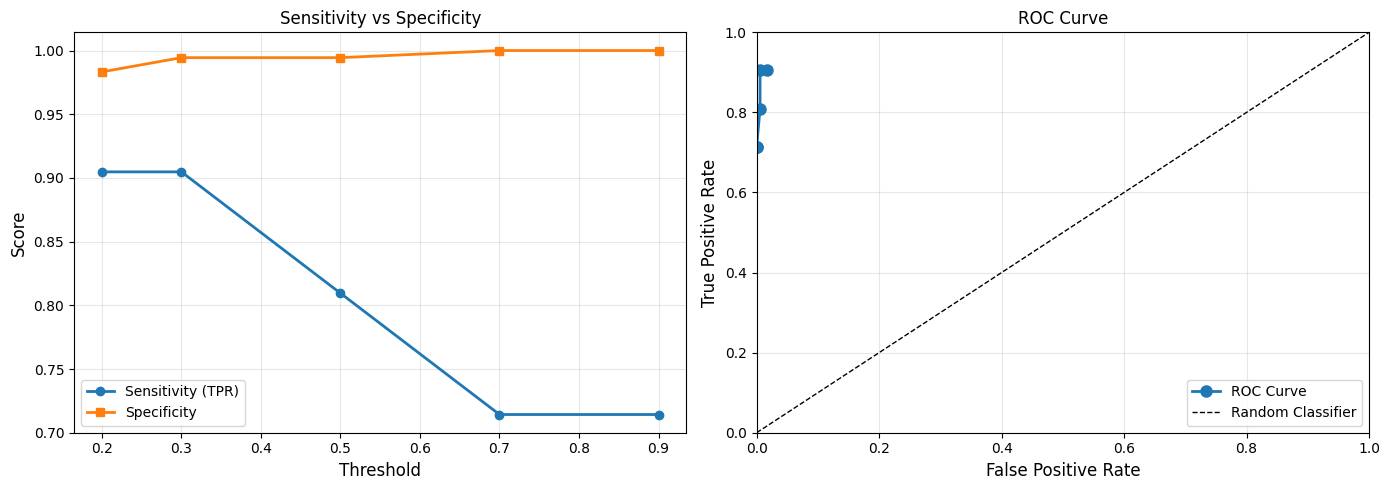

In [17]:
# Use the imbalanced data predictions
cm_imb = confusion_matrix(y_true_imb, y_pred_imb)

# Extract confusion matrix components
tn = cm_imb[0, 0]  # True Negatives
fp = cm_imb[0, 1]  # False Positives
fn = cm_imb[1, 0]  # False Negatives
tp = cm_imb[1, 1]  # True Positives

print(f"\nConfusion Matrix Components:")
print(f"  TP (True Positives):   {tp}")
print(f"  TN (True Negatives):   {tn}")
print(f"  FP (False Positives):  {fp}")
print(f"  FN (False Negatives):  {fn}")

# Calculate custom metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Also called Recall
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nCustom Metrics:")
print(f"  Sensitivity (Recall): {sensitivity:.4f} - How many actual positives were caught")
print(f"  Specificity:          {specificity:.4f} - How many actual negatives were correctly identified")
print(f"  False Positive Rate:  {false_positive_rate:.4f} - Proportion of negatives incorrectly classified as positive")
print(f"  False Negative Rate:  {false_negative_rate:.4f} - Proportion of positives incorrectly classified as negative")

# ROC-like metrics
print(f"\nROC Curve Components:")
print(f"  TPR (True Positive Rate)  = Sensitivity = {sensitivity:.4f}")
print(f"  FPR (False Positive Rate) = {false_positive_rate:.4f}")

# Visualize custom metrics across thresholds
thresholds_extended = [0.2, 0.3, 0.5, 0.7, 0.9]
custom_metrics_results = []

for threshold in thresholds_extended:
    test_preds_th = (test_probs_imb > threshold).long()
    y_pred_th = test_preds_th.cpu().numpy().squeeze()
    
    cm_th = confusion_matrix(y_true_imb, y_pred_th)
    tn_th = cm_th[0, 0]
    fp_th = cm_th[0, 1]
    fn_th = cm_th[1, 0]
    tp_th = cm_th[1, 1]
    
    sens = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0
    spec = tn_th / (tn_th + fp_th) if (tn_th + fp_th) > 0 else 0
    fpr = fp_th / (fp_th + tn_th) if (fp_th + tn_th) > 0 else 0
    fnr = fn_th / (fn_th + tp_th) if (fn_th + tp_th) > 0 else 0
    
    custom_metrics_results.append({
        'Threshold': threshold,
        'Sensitivity': sens,
        'Specificity': spec,
        'FPR': fpr,
        'FNR': fnr
    })

# Plot custom metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sensitivity vs Specificity
thresholds_list = [r['Threshold'] for r in custom_metrics_results]
sensitivity_list = [r['Sensitivity'] for r in custom_metrics_results]
specificity_list = [r['Specificity'] for r in custom_metrics_results]

axes[0].plot(thresholds_list, sensitivity_list, 'o-', label='Sensitivity (TPR)', linewidth=2)
axes[0].plot(thresholds_list, specificity_list, 's-', label='Specificity', linewidth=2)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Sensitivity vs Specificity', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: ROC Curve (FPR vs TPR)
fpr_list = [r['FPR'] for r in custom_metrics_results]
tpr_list = [r['Sensitivity'] for r in custom_metrics_results]

axes[1].plot(fpr_list, tpr_list, 'o-', linewidth=2, markersize=8, label='ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Exercise 5: Per-class metrics for multi-class
- Calculate precision/recall/F1 for each class separately
- Which class is hardest to classify?

Per-Class Metrics for Multi-class Classification:

Class 0:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   50

Class 1:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   50

Class 2:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   50

Class 3:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Support:   50

Hardest class to classify: Class 0 (F1=1.0000)
Easiest class to classify: Class 0 (F1=1.0000)


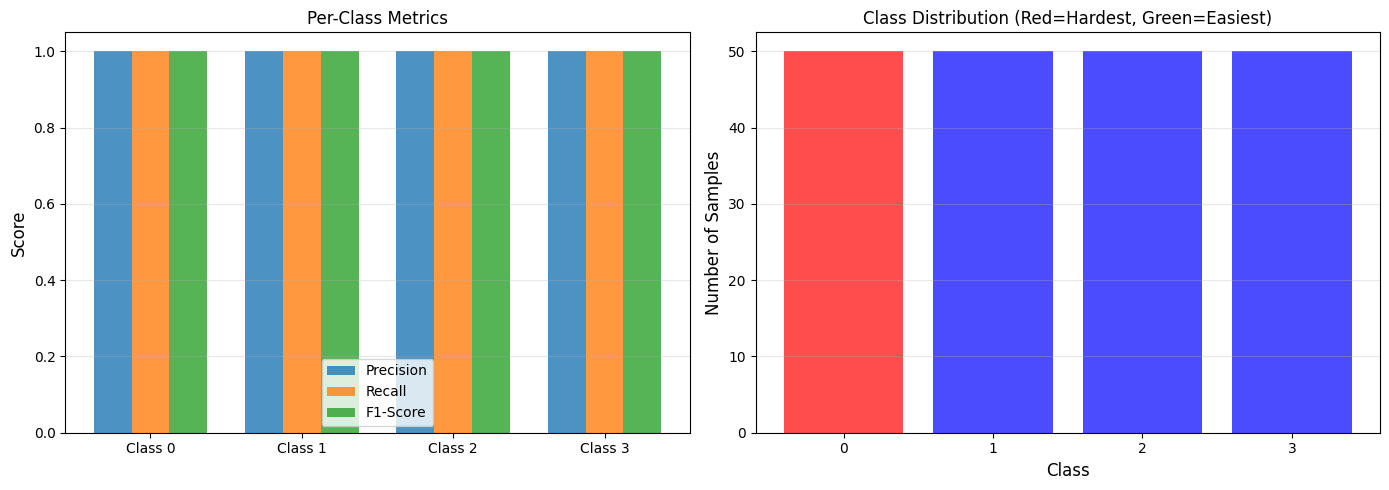

In [ ]:
# Calculate per-class metrics for multi-class classification
print("Per-Class Metrics for Multi-class Classification:\n")

per_class_metrics = []
num_classes = 4

for class_id in range(num_classes):
    # One-vs-rest approach: treat each class as positive, rest as negative
    y_true_binary = (y_true_m == class_id).astype(int)
    y_pred_binary = (y_pred_m == class_id).astype(int)
    
    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    rec = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    
    # Count support (number of samples in each class)
    support = (y_true_m == class_id).sum()
    
    per_class_metrics.append({
        'Class': class_id,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Support': support
    })
    
    print(f"Class {class_id}:")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Support:   {support}\n")

# Find hardest and easiest class to classify
f1_scores = [m['F1-Score'] for m in per_class_metrics]
hardest_class = per_class_metrics[np.argmin(f1_scores)]['Class']
easiest_class = per_class_metrics[np.argmax(f1_scores)]['Class']

# Visualize per-class metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per-class metrics comparison
class_ids = [m['Class'] for m in per_class_metrics]
precisions = [m['Precision'] for m in per_class_metrics]
recalls = [m['Recall'] for m in per_class_metrics]
f1_scores_list = [m['F1-Score'] for m in per_class_metrics]

x = np.arange(len(class_ids))
width = 0.25

axes[0].bar(x - width, precisions, width, label='Precision', alpha=0.8)
axes[0].bar(x, recalls, width, label='Recall', alpha=0.8)
axes[0].bar(x + width, f1_scores_list, width, label='F1-Score', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Per-Class Metrics', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Class {c}' for c in class_ids])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Support distribution
supports = [m['Support'] for m in per_class_metrics]
colors = ['red' if class_ids[i] == hardest_class else 'green' if class_ids[i] == easiest_class else 'blue' 
        for i in range(len(class_ids))]
axes[1].bar(class_ids, supports, color=colors, alpha=0.7)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Class Distribution (Red=Hardest, Green=Easiest)', fontsize=12)
axes[1].set_xticks(class_ids)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()